In [ ]:
import os
from kan import *
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
import numpy as np
import torch
import HydroErr as he
from sklearn.linear_model import LinearRegression
from joblib import Parallel, delayed
import itertools
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


In [ ]:
base = os.getcwd()  # get current working directory

# Full file path
dir_in = os.path.join(base, "V5.xlsx")

In [3]:
def to_numpy_1d(array_like):
    if isinstance(array_like, torch.Tensor):
        array_like = array_like.detach().cpu().numpy()
    return np.ravel(array_like)

In [ ]:
def model_performance(sim_train, obs_train, sim_test, obs_test, additional_metrics=None):
    sim_train = to_numpy_1d(sim_train)
    obs_train = to_numpy_1d(obs_train)
    sim_test = to_numpy_1d(sim_test)
    obs_test = to_numpy_1d(obs_test)

    metrics = {
        'R^2': he.r_squared,
        'RMSE': he.rmse,
        'KGE': he.kge_2012,
        'NSE': he.nse
    }

    if additional_metrics:
        metrics.update(additional_metrics)

    def evaluate_metrics(sim, obs):
        return {name: func(sim, obs) for name, func in metrics.items()}

    # ----- Linear regression m,q -----
    try:
        lr_train = LinearRegression().fit(obs_train.reshape(-1,1), sim_train)
        m_train = lr_train.coef_[0]
        q_train = lr_train.intercept_
    except:
        m_train, q_train = np.nan, np.nan

    try:
        lr_test = LinearRegression().fit(obs_test.reshape(-1,1), sim_test)
        m_test = lr_test.coef_[0]
        q_test = lr_test.intercept_
    except:
        m_test, q_test = np.nan, np.nan

    train_results = evaluate_metrics(sim_train, obs_train)
    test_results = evaluate_metrics(sim_test, obs_test)

    print(f"\n=== Model performance on training data ===")
    for name, value in train_results.items():
        print(f"{name} (train): {value:.4f}")
    print(f"m (train): {m_train:.4f}")
    print(f"q (train): {q_train:.4f}")

    print(f"\n=== Model performance on test data ===")
    for name, value in test_results.items():
        print(f"{name} (test): {value:.4f}")
    print(f"m (test): {m_test:.4f}")
    print(f"q (test): {q_test:.4f}")


In [ ]:
def average_r2(df_all, opt, lamb, lamb_coef, grid, seed, lib, 
               x_labels, y_label='ZTP(km)', n_splits=10,
               random_state=0, verbose=0, return_folds=True):

    X_all = df_all[x_labels].copy()
    y_all = df_all[y_label].values.reshape(-1, 1).copy()

    X, X_test_global, y, y_test_global = train_test_split(
        X_all, y_all, test_size=0.2, random_state=random_state
    )

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    list_r2_test = []
    fold_results = []

    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        print(f'\nFold {fold + 1}')
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y[train_index], y[test_index]

        X_train_t = torch.from_numpy(X_train.values).float()
        X_test_t = torch.from_numpy(X_test.values).float()
        y_train_t = torch.from_numpy(y_train).float()
        y_test_t = torch.from_numpy(y_test).float()

        dataset = {
            'train_input': X_train_t,
            'test_input': X_test_t,
            'train_label': y_train_t,
            'test_label': y_test_t
        }

        model = KAN(width=[X_train_t.shape[1],2, 1], grid=grid, k=3, seed=seed, auto_save=False)
        model(dataset['train_input'])
        model.fit(dataset, opt=opt, steps=20, lamb=lamb, lamb_coef=lamb_coef)

        for _ in range(2):
            model.fit(dataset, opt=opt, steps=50, lamb=lamb, lamb_coef=lamb_coef)

        try:
            model.auto_symbolic(lib=lib, weight_simple=0.8)
            model.fit(dataset, opt=opt, steps=20, lamb=lamb, lamb_coef=lamb_coef)
        except:
            pass

        y_train_pred = model(X_train_t)
        y_test_pred = model(X_test_t)

        r2_train = he.r_squared(y_train_pred.detach().numpy()[:, 0], y_train.flatten())
        r2_test = he.r_squared(y_test_pred.detach().numpy()[:, 0], y_test.flatten())

        list_r2_test.append(r2_test)

        eqn = model.symbolic_formula()[0][0]

        if verbose > 0:
            print(f"... KAN eqn: {eqn}")
            print(f"... R^2 train: {r2_train:.4f}")
            print(f"... R^2 test: {r2_test:.4f}")

            # global test
            y_pred_global = model(torch.from_numpy(X_test_global.values).float())
            model_performance(
                sim_train=model(torch.from_numpy(X.values).float()),
                obs_train=y.flatten(),
                sim_test=y_pred_global,
                obs_test=y_test_global.flatten()
            )

        fold_results.append({
            'fold': fold + 1,
            'X_train': X_train.values,
            'y_train_obs': y_train.copy(),
            'y_train_pred': y_train_pred.detach().numpy(),
            'X_test': X_test.values,
            'y_test_obs': y_test.copy(),
            'y_test_pred': y_test_pred.detach().numpy(),
            'model': model,
            'eqn': eqn
        })

    avg_r2 = np.nanmean(list_r2_test)

    if return_folds:
        return avg_r2, fold_results
    else:
        return avg_r2


In [ ]:
# Load the dataset
df_all = pd.read_excel(dir_in)

In [ ]:
# Parameters
opt = "LBFGS"
lamb = 1e-3 
lamb_coef = 0.0
lib = ['x', 'x^2', 'x^3', 'x^4', 'x^5', 'sin', 'cos', 'exp', 'gaussian', 'tanh']

In [ ]:
# specify the input columns
x_labels = ['CO2', 'N2' , 'O2', 'CH4', 'H2', 'Ar', 'p0', 'T0', 'u0', 'D', 'sp', 'Tamb', 'h']

In [ ]:
seed_range = range(0, 2)
grid_range = range(2, 4)

param_list = list(itertools.product(seed_range, grid_range))

def run_single(seed, grid):

    avg_r2, _ = average_r2(df_all, opt, lamb, lamb_coef, grid, seed, lib, x_labels=x_labels, y_label='Ptp', n_splits=10, random_state=5)

    return (seed, grid, avg_r2)

results = Parallel(n_jobs=-1, backend="loky")(delayed(run_single)(seed, grid) for seed, grid in param_list)

best_seed, best_grid, best_r2 = max(results, key=lambda x: x[2])

print(f"Best parameters found:\nSeed: {best_seed}\nGrid: {best_grid}\nBest average R²: {best_r2}")

Best parameters found:
Seed: 0
Grid: 3
Best average R²: 0.8677240142930398


In [16]:
best_avg, fold_results = average_r2(df_all, opt, lamb, lamb_coef, best_grid, best_seed, lib, x_labels=x_labels, y_label='Ptp', n_splits=10, random_state=5, verbose=2)


Fold 1


| train_loss: 5.05e-01 | test_loss: 5.32e-01 | reg: 4.70e+01 | : 100%|█| 20/20 [00:05<00:00,  3.98it
| train_loss: 3.12e-01 | test_loss: 3.24e-01 | reg: 2.58e+01 | : 100%|█| 50/50 [00:12<00:00,  4.11it
| train_loss: 3.09e-01 | test_loss: 4.11e-01 | reg: 2.17e+01 | : 100%|█| 50/50 [00:12<00:00,  3.98it


fixing (0,0,0) with sin, r2=0.9996880888938904, c=2
fixing (0,0,1) with x^2, r2=0.9991241097450256, c=2
fixing (0,1,0) with x, r2=0.9968721270561218, c=1
fixing (0,1,1) with cos, r2=0.9847590327262878, c=2
fixing (0,2,0) with x, r2=0.45388224720954895, c=1
fixing (0,2,1) with x, r2=0.007197600789368153, c=1
fixing (0,3,0) with x, r2=0.9742466807365417, c=1
fixing (0,3,1) with x, r2=0.0012242356315255165, c=1
fixing (0,4,0) with x, r2=0.9907814264297485, c=1
fixing (0,4,1) with x, r2=0.884124219417572, c=1
fixing (0,5,0) with x, r2=0.3359871208667755, c=1
fixing (0,5,1) with x, r2=0.6810986399650574, c=1
fixing (0,6,0) with x, r2=0.9980006217956543, c=1
fixing (0,6,1) with x, r2=0.9981728196144104, c=1
fixing (0,7,0) with x, r2=0.9985803365707397, c=1
fixing (0,7,1) with x, r2=0.9997546672821045, c=1
fixing (0,8,0) with x^2, r2=0.9999999403953552, c=2
fixing (0,8,1) with sin, r2=1.0000005960464478, c=2
fixing (0,9,0) with x, r2=0.9708248972892761, c=1
fixing (0,9,1) with x, r2=0.6865869

| train_loss: 3.55e-01 | test_loss: 3.69e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:08<00:00,  2.32it


... KAN eqn: -0.14474863687782*x_10 - 1.76118725425173*x_11 + 0.00738655347808812*x_3 + 0.0178556152159062*x_4 + 0.617389371893035*x_5 - 0.0905585180609676*x_6 + 0.301698050312262*x_7 - 0.0939329044838336*x_8 + 0.254311368283909*(1 - 0.877814358122851*x_1)**2 - 0.738221649488692*(1 - 0.113354289522027*x_13)**2 - 1.28838064001102*sin(7.99427700042725*x_12 - 8.90561008453369) - 0.261543372661669*sin(3.00559234619141*x_9 + 1.4496818780899) + 6.1556978225708*sin(0.0609334376547032*x_10 + 0.622868396429742*x_11 + 0.853810662698627*x_2 - 0.173166216710685*x_3 - 2.60331395539301*x_4 + 9.51650997927741*x_5 - 0.616363741371626*x_6 - 0.0633777250119821*x_7 + 0.023039564129956*x_8 + 0.924932145300751*(1 - 0.323312264521199*x_9)**2 - 2.25693880763902*sin(3.03442549705505*x_1 + 9.15258407592773) + 3.85228639881733 + 0.142238168201953*exp(-0.310630232095718*x_13) - 4.719201024495*exp(-0.00259083649143577*x_12)) - 0.0151883256013455*cos(10.0000352859497*x_2 + 4.97558927536011) + 3.58727477816479
... 

...

... KAN eqn: nan
... R^2 train: nan
... R^2 test: nan

=== Model performance on training data ===
R^2 (train): nan
RMSE (train): nan
KGE (train): nan
NSE (train): nan
m (train): nan
q (train): nan

=== Model performance on test data ===
R^2 (test): nan
RMSE (test): nan
KGE (test): nan
NSE (test): nan
m (test): nan
q (test): nan

Fold 10


| train_loss: 4.71e-01 | test_loss: 4.02e-01 | reg: 5.30e+01 | : 100%|█| 20/20 [00:05<00:00,  3.83it
| train_loss: 4.15e-01 | test_loss: 3.84e-01 | reg: 4.26e+01 | : 100%|█| 50/50 [00:13<00:00,  3.83it
| train_loss: 3.40e-01 | test_loss: 3.72e-01 | reg: 4.03e+01 | : 100%|█| 50/50 [00:12<00:00,  3.93it


fixing (0,0,0) with x, r2=0.0200345441699028, c=1
fixing (0,0,1) with cos, r2=0.9998155236244202, c=2
fixing (0,1,0) with x, r2=0.002267673145979643, c=1
fixing (0,1,1) with x, r2=0.9995943903923035, c=1
fixing (0,2,0) with x, r2=0.0024167310912162066, c=1
fixing (0,2,1) with x, r2=0.9452027678489685, c=1
fixing (0,3,0) with x, r2=0.001081123249605298, c=1
fixing (0,3,1) with x, r2=0.9674825072288513, c=1
fixing (0,4,0) with exp, r2=0.9857457876205444, c=2
fixing (0,4,1) with exp, r2=1.0000005960464478, c=2
fixing (0,5,0) with exp, r2=0.9508478045463562, c=2
fixing (0,5,1) with x, r2=0.005590246059000492, c=1
fixing (0,6,0) with x, r2=0.9960441589355469, c=1
fixing (0,6,1) with x, r2=0.9873124957084656, c=1
fixing (0,7,0) with x, r2=0.9998816251754761, c=1
fixing (0,7,1) with x, r2=0.9983856081962585, c=1
fixing (0,8,0) with x^2, r2=1.0000005960464478, c=2
fixing (0,8,1) with sin, r2=0.9999960064888, c=2
fixing (0,9,0) with x, r2=0.9980951547622681, c=1
fixing (0,9,1) with sin, r2=0.99

| train_loss: 3.38e-01 | test_loss: 3.63e-01 | reg: 0.00e+00 | : 100%|█| 20/20 [00:03<00:00,  6.12it


... KAN eqn: 15.3234266227247*exp(-0.00019383827204674*x_1 - 0.00197847329778698*x_10 + 0.00193492685695962*x_11 - 0.00334547280614636*x_12 - 2.33802304704847e-5*x_2 + 7.32260259388151e-5*x_3 - 7.84427135910052e-5*x_4 + 0.0165530140637278*x_7 - 0.00756675358202961*x_8 - 0.12450206203351*(1 - 0.0365248888909253*x_13)**2 - 0.103795645905976*(1 - 0.391909625501396*x_9)**2 - 0.0117636902895992*exp(9.99987983703613*x_6) + 0.00530755430802983*exp(-10.0*x_5)) + 6.4721508026123*sin(0.244266455863176*x_11 + 1.5462639644146*x_2 + 0.296852901217249*x_3 - 1.16087004941527*x_4 + 0.00427265111499937*x_6 - 0.0476995117298709*x_7 + 0.0247354741317755*x_8 + 0.118483412250784*(1 - 0.127733412652633*x_13)**2 + 1.08347580285415*exp(8.80062961578369*x_5) + 0.00567855070191081*sin(5.52424001693726*x_10 + 9.71088027954102) + 0.186782042028071*sin(5.75036764144897*x_12 + 7.52083539962769) + 0.0361046313481017*sin(8.15285396575928*x_9 + 6.31792211532593) + 1.0408901965198*cos(4.59159708023071*x_1 + 9.600221633

In [ ]:
def plot_predictions_single_output(df_all, fold_results, x_labels, y_label='ZTP(me-5)', random_state=5):

    X_all = df_all[x_labels].copy()
    y_all = df_all[y_label].values.reshape(-1, 1).copy()

    X_train_gl, X_test_gl, y_train_gl, y_test_gl = train_test_split(
        X_all, y_all, test_size=0.2, random_state=random_state
    )

    X_train_t = torch.from_numpy(X_train_gl.values).float()
    X_test_t = torch.from_numpy(X_test_gl.values).float()

    for i, fold in enumerate(fold_results):

        # Check if the model exists
        if 'model' not in fold or fold['model'] is None:
            print(f"Fold {fold.get('fold', i+1)} saltato: modello non disponibile.")
            continue


        model = fold['model']

        # predictions on global train and test
        try:
            y_train_pred = model(X_train_t).detach().numpy()
            y_test_pred = model(X_test_t).detach().numpy()
        except Exception as e:
            print(f"Fold {fold.get('fold', i+1)} saltato: errore durante predizione ({e})")
            continue

        # Check NaN
        if np.isnan(y_train_pred).any() or np.isnan(y_test_pred).any():
            print(f"Fold {fold.get('fold', i+1)} saltato: predizioni contengono NaN")
            continue

        y_obs_all = np.concatenate([y_train_gl.flatten(), y_test_gl.flatten()])
        y_pred_all = np.concatenate([y_train_pred, y_test_pred])

        plt.figure(figsize=(6,5))

        plt.scatter(y_train_gl, y_train_pred, alpha=0.6, label='Train (80%)')
        plt.scatter(y_test_gl, y_test_pred, alpha=0.6, label='Test (20%)')

        min_val = min(y_obs_all.min(), y_pred_all.min())
        max_val = max(y_obs_all.max(), y_pred_all.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Bisettrice')

       

        lr = LinearRegression().fit(y_obs_all.reshape(-1,1), y_pred_all)
        r2 = lr.score(y_obs_all.reshape(-1,1), y_pred_all)
        m = float(lr.coef_.ravel()[0])
        q = float(np.array(lr.intercept_).ravel()[0])


        txt = f"R²: {r2:.3f}\nm: {m:.3f}\nq: {q:.3f}"
        plt.text(0.05, 0.95, txt, transform=plt.gca().transAxes,
                 va='top', bbox=dict(facecolor='white', alpha=0.8))

        plt.xlabel("Osservato")
        plt.ylabel("Predetto")
        plt.title(f"Fold {fold['fold']} – {y_label}")
        plt.legend(loc='lower right', fontsize=14)
        plt.grid(True)

        plt.show()

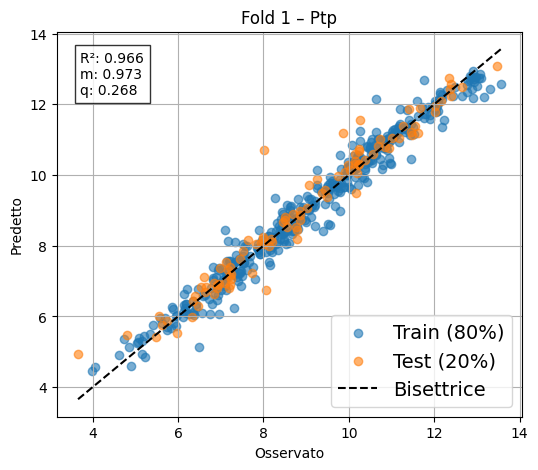

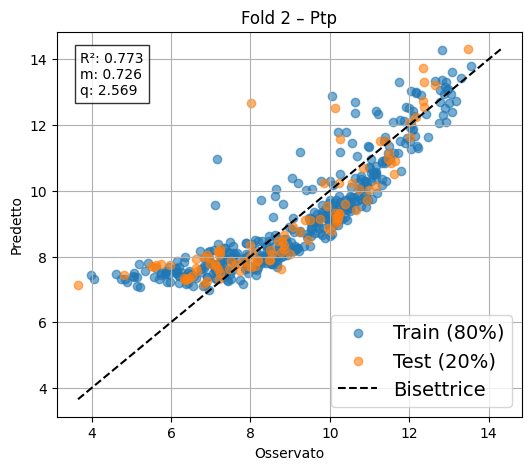

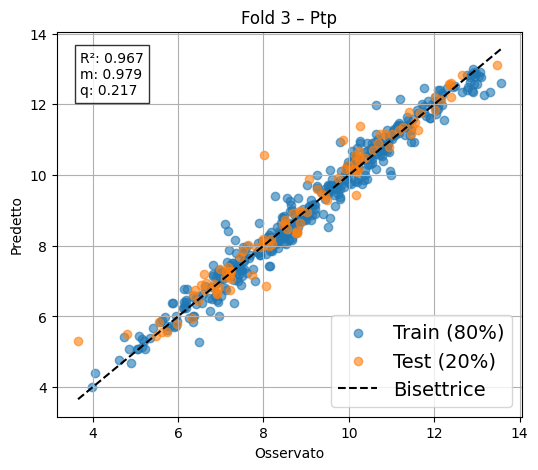

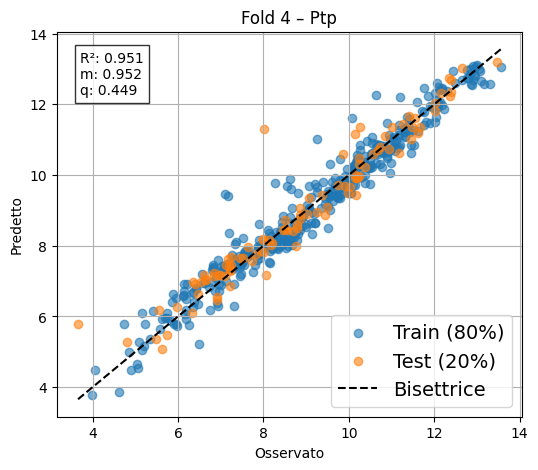

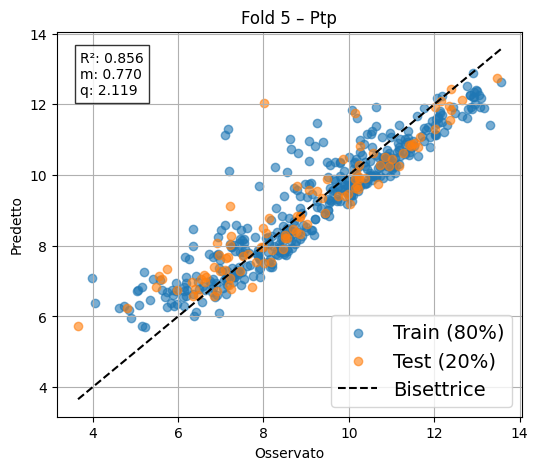

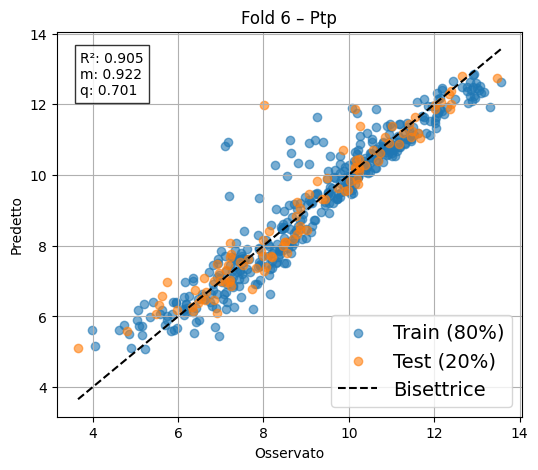

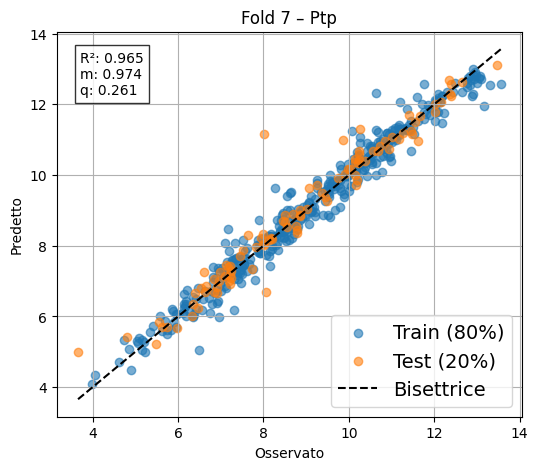

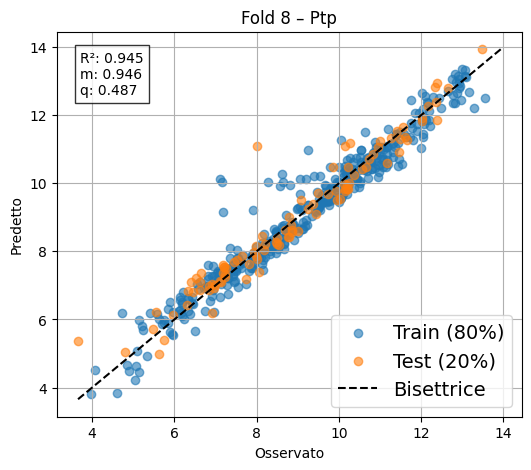

Fold 9 saltato: predizioni contengono NaN


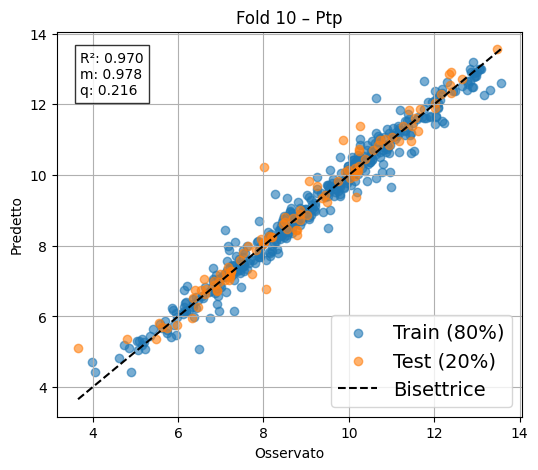

In [19]:
plot_predictions_single_output(df_all, fold_results, x_labels=x_labels, y_label='Ptp', random_state=5)

In [ ]:
def plot_train_test_for_single_fold(df_all, fold_results, fold_number,
                                    x_labels, y_label, random_state=5):

    # Check if the fold exists
    selected = None
    for fr in fold_results:
        if fr.get("fold", None) == fold_number:
            selected = fr
            break

    if selected is None or selected.get("model", None) is None:
        print(f"Fold {fold_number} non trovato o modello non disponibile.")
        return

    model = selected["model"]

    X_all = df_all[x_labels].copy()
    y_all = df_all[y_label].values.reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=random_state
    )

    X_train_t = torch.from_numpy(X_train.values).float()
    X_test_t = torch.from_numpy(X_test.values).float()

    # Predictions
    y_pred_train = model(X_train_t).detach().numpy().flatten()
    y_pred_test  = model(X_test_t).detach().numpy().flatten()

    y_train_flat = y_train.flatten()
    y_test_flat  = y_test.flatten()

    # Train metric
    r2_train = r2_score(y_train_flat, y_pred_train)
    lr_train = LinearRegression().fit(y_train_flat.reshape(-1,1), y_pred_train)
    m_train = lr_train.coef_[0]
    q_train = lr_train.intercept_
    r2_lr_train = lr_train.score(y_train_flat.reshape(-1,1), y_pred_train)


    # Test metrics
    r2_test = r2_score(y_test_flat, y_pred_test)
    lr_test = LinearRegression().fit(y_test_flat.reshape(-1,1), y_pred_test)
    m_test = lr_test.coef_[0]
    q_test = lr_test.intercept_
    r2_lr_test = lr_test.score(y_test_flat.reshape(-1,1), y_pred_test)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # PLOT TRAIN
    ax[0].scatter(y_train_flat, y_pred_train, alpha=0.7, color='blue')
    min_val = min(y_train_flat.min(), y_pred_train.min())
    max_val = max(y_train_flat.max(), y_pred_train.max())
    ax[0].plot([min_val, max_val], [min_val, max_val], 'k--')
    ax[0].set_title(f"Fold {fold_number} – TRAIN")
    ax[0].set_xlabel("Osservato")
    ax[0].set_ylabel("Predetto")
    ax[0].grid(True)
    txt_train = f"R²: {r2_lr_train:.3f}\nm: {m_train:.3f}\nq: {q_train:.3f}"
    ax[0].text(0.05, 0.95, txt_train, transform=ax[0].transAxes,
               va='top', bbox=dict(facecolor='white', alpha=0.8))

    # PLOT TEST
    ax[1].scatter(y_test_flat, y_pred_test, alpha=0.7, color='orange')
    min_val = min(y_test_flat.min(), y_pred_test.min())
    max_val = max(y_test_flat.max(), y_pred_test.max())
    ax[1].plot([min_val, max_val], [min_val, max_val], 'k--')
    ax[1].set_title(f"Fold {fold_number} – TEST")
    ax[1].set_xlabel("Osservato")
    ax[1].set_ylabel("Predetto")
    ax[1].grid(True)
    txt_test = f"R²: {r2_lr_test:.3f}\nm: {m_test:.3f}\nq: {q_test:.3f}"
    ax[1].text(0.05, 0.95, txt_test, transform=ax[1].transAxes,
               va='top', bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()


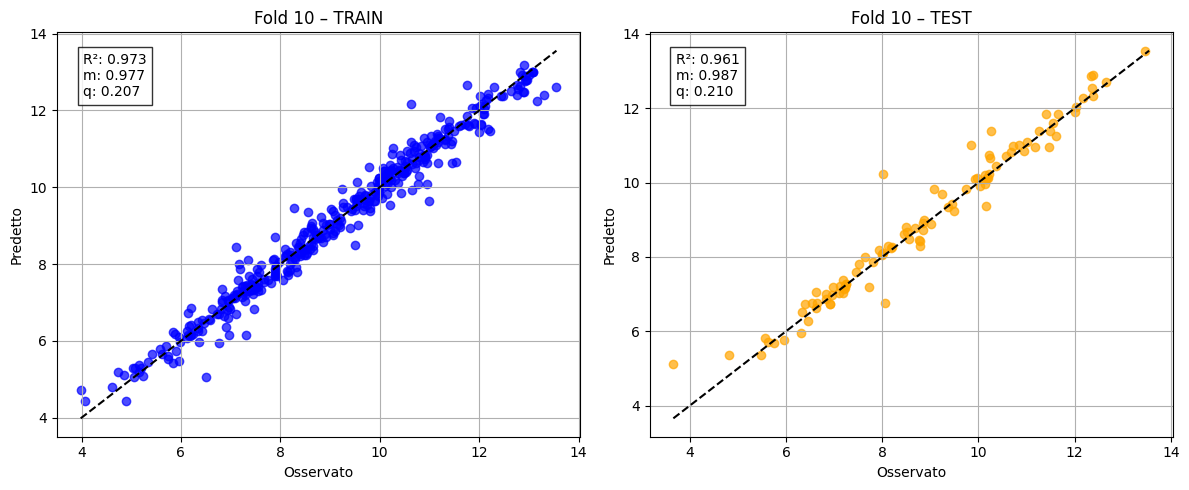

In [22]:
plot_train_test_for_single_fold(df_all, fold_results, fold_number=10, x_labels=x_labels, y_label='Ptp')